# Detecção de Anomalias em Licitações Públicas do Paraná (2020–2025)
## Pipeline Completo: Pré-processamento → Enriquecimento → ML Não-Supervisionado

---

Este notebook é **autocontido**: executa todas as etapas desde o carregamento
dos CSVs até a exportação dos resultados, seguindo o processo KDD (Fayyad et al., 1996).

### Estrutura

| Seção | Etapa KDD | Conteúdo |
|---|---|---|
| 1 | — | Importações e configurações globais |
| 2 | Seleção | Carregamento dos CSVs (2020–2025) |
| 3 | Pré-processamento | Limpeza, tipagem, normalização de texto |
| 4 | Transformação | Features derivadas dos dados de licitação |
| 5 | Seleção/Transf. | Enriquecimento com IDHM e população (IDHM-PR.csv) |
| 6 | Transformação | Engenharia de features para ML |
| 7 | Transformação | Normalização |
| 8 | Mineração | Isolation Forest |
| 9 | Mineração | Local Outlier Factor (LOF) |
| 10 | Mineração | Score ensemble e classificação |
| 11 | Interpretação | Visualizações e perfil das anomalias |
| 12 | — | Exportação dos resultados |
| 13 | — | Sumário final e limitações |

### Por que detecção não-supervisionada?

O dataset **não possui rótulos** — nenhum registro está previamente marcado como
fraudulento ou irregular. Sem rótulos, não é possível treinar classificadores
supervisionados. A abordagem detecta **desvios estatísticos** sem exemplos rotulados
(Chandola, Banerjee e Kumar, 2009).

Dois algoritmos complementares são combinados:

- **Isolation Forest** (Liu, Ting & Zhou, 2008): detecta anomalias globais — pontos
  raros são isolados com poucos cortes aleatórios nas árvores.
- **LOF** (Breunig et al., 2000): detecta anomalias locais — pontos incomuns em
  relação à sua vizinhança imediata.

### Referências
- Liu, Ting e Zhou (2008): Isolation Forest — IEEE ICDM
- Breunig et al. (2000): LOF — ACM SIGMOD
- Chandola, Banerjee e Kumar (2009): Anomaly Detection Survey — ACM CSUR
- Fayyad, Piatetsky-Shapiro e Smyth (1996): KDD
- Lundberg e Lee (2017): SHAP — NeurIPS
- Lei 14.133/2021: Nova Lei de Licitações e Contratos Administrativos


---
## 1 — Importações e Configurações Globais

In [19]:
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, FileLink

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# SHAP: interpretabilidade por instância (opcional — pip install shap)
try:
    import shap
    SHAP_DISPONIVEL = True
    print('SHAP disponível')
except ImportError:
    SHAP_DISPONIVEL = False
    print('SHAP não instalado — análise por z-score será usada como alternativa')

# ---------------------------------------------------------------------------
# CONFIGURAÇÕES GLOBAIS
# ---------------------------------------------------------------------------
pd.options.display.max_columns  = 50
pd.options.display.max_colwidth = 120
pd.options.display.float_format  = lambda x: f'{x:,.2f}'

EXPORTS_DIR  = Path('exports')
EXPORTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# Valor mínimo para que valor_estimado seja considerado financeiramente válido.
# Registros com valor_estimado abaixo deste patamar (ex: R$100, R$1) são erros
# de cadastro — quando cruzados com valor_homologado real, geram sobrepreços
# fictícios de milhões de porcento que distorcem completamente os resultados.
# Justificativa: o menor limite de dispensa da Lei 14.133/2021 (Art. 75)
# é R$50.000 — qualquer licitação real tem estimativa na casa dos milhares.
VALOR_ESTIMADO_MIN = 10_000  # R$ 10.000

print('Configuração concluída.')


SHAP disponível
Configuração concluída.


---
## 2 — Seleção dos Dados

Carregamos os seis arquivos CSV de licitações públicas do Estado do Paraná
(um por ano, 2020–2025) e os concatenamos em um único DataFrame.

Todos os campos são lidos como texto (`dtype=str`) para evitar conversões
automáticas incorretas — a tipagem correta é feita na próxima seção.


In [20]:
csv_paths = [
    Path('./data/TB_LICITACOES-2025.csv'),
    Path('./data/TB_LICITACOES-2024.csv'),
    Path('./data/TB_LICITACOES-2023.csv'),
    Path('./data/TB_LICITACOES-2022.csv'),
    Path('./data/TB_LICITACOES-2021.csv'),
    Path('./data/TB_LICITACOES-2020.csv'),
]

frames = []
for path_csv in csv_paths:
    if not path_csv.exists():
        print(f'  AVISO: {path_csv.name} não encontrado — ignorado')
        continue
    frame = (
        pd.read_csv(path_csv, sep=';', dtype=str)
            .rename(columns=str.lower)
            .assign(arquivo=path_csv.name)
    )
    frames.append(frame)
    print(f'  {path_csv.name}: {len(frame):,} registros')

raw_df = pd.concat(frames, ignore_index=True)

print(f'\nTotal carregado: {len(raw_df):,} registros')
print(f'Colunas brutas ({raw_df.shape[1]}): {raw_df.columns.tolist()}')


  TB_LICITACOES-2025.csv: 1,732 registros
  TB_LICITACOES-2024.csv: 2,645 registros
  TB_LICITACOES-2023.csv: 2,725 registros
  TB_LICITACOES-2022.csv: 2,708 registros
  TB_LICITACOES-2021.csv: 2,028 registros
  TB_LICITACOES-2020.csv: 1,698 registros

Total carregado: 13,536 registros
Colunas brutas (19): ['numprocesso', 'ano', 'modalidade', 'situacao', 'objeto', 'orgao', 'registrodepreco', 'vigenciaata', 'revogacaoata', 'criteriojulgamento', 'valor_estimado', 'valor_ou_desconto_homologado', 'dataabertura', 'datahomologacao', 'localdisputa', 'idlicitacoes', 'protocolo', 'tempoprazocontrato', 'arquivo']


---
## 3 — Pré-processamento

Transformamos os dados brutos em um formato utilizável:

1. **Remoção de colunas irrelevantes** para a análise de anomalias
2. **Conversão de datas** (`dataabertura`, `datahomologacao`) para `datetime`
3. **Conversão de valores monetários** do formato brasileiro para `float`
4. **Normalização do texto** (`objeto`) para facilitar classificação por palavras-chave

Ao final imprimimos o perfil completo do dataset resultante — colunas, tipos
e percentual de preenchimento de cada campo.


In [21]:
def para_datetime(series, fmt='%Y-%m-%d'):
    """Converte Series de strings para datetime; erros viram NaT."""
    return pd.to_datetime(series, format=fmt, errors='coerce')


def converter_valor_br(series):
    """
    Converte string monetária brasileira para float.
    Exemplo: '1.234.567,89'  →  1234567.89
    """
    return pd.to_numeric(
        series
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    )


clean_df = raw_df.copy()

# ---------------------------------------------------------------------------
# 3.1 — Remoção de colunas
# registrodepreco    → binário sem valor analítico direto
# vigenciaata        → aplicável só a contratos, fora do escopo
# revogacaoata       → idem
# localdisputa       → não influencia detecção de anomalias financeiras
# idlicitacoes       → identificador interno
# protocolo          → idem
# tempoprazocontrato → texto livre não estruturado
# ---------------------------------------------------------------------------
colunas_remover = [
    'registrodepreco', 'vigenciaata', 'revogacaoata',
    'localdisputa', 'idlicitacoes', 'protocolo', 'tempoprazocontrato'
]
clean_df = clean_df.drop(columns=colunas_remover, errors='ignore')

# ---------------------------------------------------------------------------
# 3.2 — Conversão de datas
# ---------------------------------------------------------------------------
clean_df['dataabertura']    = para_datetime(clean_df['dataabertura'])
clean_df['datahomologacao'] = para_datetime(clean_df['datahomologacao'])

# ---------------------------------------------------------------------------
# 3.3 — Conversão de valores monetários
# ---------------------------------------------------------------------------
for col in ['valor_estimado', 'valor_ou_desconto_homologado']:
    if col in clean_df.columns:
        clean_df[col] = converter_valor_br(clean_df[col])

# ---------------------------------------------------------------------------
# 3.4 — Normalização do texto do objeto
# ---------------------------------------------------------------------------
clean_df['objeto_normalizado'] = (
    clean_df['objeto']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# ---------------------------------------------------------------------------
# PERFIL DO DATASET APÓS PRÉ-PROCESSAMENTO
# ---------------------------------------------------------------------------
print('=' * 65)
print('DATASET APÓS PRÉ-PROCESSAMENTO')
print('=' * 65)
print(f'  Registros : {len(clean_df):,}')
print(f'  Colunas   : {clean_df.shape[1]}')
print()
print(f'  {"Coluna":<42} {"Tipo":<14} Preenchimento')
print(f'  {"-"*42} {"-"*14} {"-"*14}')
for col in clean_df.columns:
    n_nulos = clean_df[col].isna().sum()
    pct_ok  = (1 - n_nulos / len(clean_df)) * 100
    print(f'  {col:<42} {str(clean_df[col].dtype):<14} {pct_ok:>6.1f}%')

print()
display(clean_df.head(3))


DATASET APÓS PRÉ-PROCESSAMENTO
  Registros : 13,536
  Colunas   : 13

  Coluna                                     Tipo           Preenchimento
  ------------------------------------------ -------------- --------------
  numprocesso                                object          100.0%
  ano                                        object          100.0%
  modalidade                                 object          100.0%
  situacao                                   object          100.0%
  objeto                                     object          100.0%
  orgao                                      object          100.0%
  criteriojulgamento                         object          100.0%
  valor_estimado                             float64          97.7%
  valor_ou_desconto_homologado               float64          63.8%
  dataabertura                               datetime64[ns]   99.9%
  datahomologacao                            datetime64[ns]   79.5%
  arquivo                        

,numprocesso,ano,modalidade,situacao,objeto,orgao,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,arquivo,objeto_normalizado
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,-,0.00,NaN,2025-02-19,NaT,TB_LICITACOES-2025.csv,audiência pública visa consultar os eventuais interessados no credenciamento de entidades médicas e psicológicas de ...
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Menor Preço,0.00,NaN,2025-05-22,NaT,TB_LICITACOES-2025.csv,audiência pública do programa ganhando o mundo.
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Menor Preço,0.00,NaN,2025-06-04,NaT,TB_LICITACOES-2025.csv,audiência pública que visa obter contribuições para compor o estudo técnico preliminar e termo de referência para po...


---
## 4 — Transformação: Features Derivadas

Criamos variáveis que não existem diretamente nos dados mas capturam padrões
relevantes para detecção de anomalias:

| Variável | Como é calculada | O que captura |
|---|---|---|
| `proporcao_homologado_estimado` | homologado / estimado | > 1 = sobrepreço; < 1 = desconto |
| `flag_sobrepreco` | proporção > 1 | Flag binária de sobrepreço |
| `lead_time_dias` | (datahomologacao − dataabertura).days | Duração do processo |
| `ano_abertura` | dataabertura.year | Ano do certame |
| `volume_licitacoes_orgao_ano` | count por (orgao, ano) | Volume anual do órgão |


In [22]:
v_est = clean_df['valor_estimado'].fillna(0)
v_hom = clean_df['valor_ou_desconto_homologado'].fillna(0)

# ---------------------------------------------------------------------------
# Condição de validade financeira
# Só calculamos sobrepreço quando:
#   (a) valor_estimado >= VALOR_ESTIMADO_MIN — elimina placeholders tipo R$100
#   (b) valor_homologado > 0 — processo efetivamente homologado com valor
# ---------------------------------------------------------------------------
cond_financeiro = (v_est >= VALOR_ESTIMADO_MIN) & (v_hom > 0)

n_invalidos = ((v_est > 0) & (v_est < VALOR_ESTIMADO_MIN)).sum()
print(f'Registros com valor_estimado inválido (< R${VALOR_ESTIMADO_MIN:,.0f}): '
      f'{n_invalidos:,} — excluídos da análise financeira')

# Proporção homologado/estimado — cap em 10x para não distorcer o scaler
clean_df['proporcao_homologado_estimado'] = np.where(
    cond_financeiro,
    np.clip(v_hom / v_est, 0, 10),
    np.nan
)
clean_df['flag_sobrepreco'] = clean_df['proporcao_homologado_estimado'] > 1

# ---------------------------------------------------------------------------
# Lead time — prazos negativos (erro de data) são zerados
# ---------------------------------------------------------------------------
clean_df['lead_time_dias'] = (
    (clean_df['datahomologacao'] - clean_df['dataabertura'])
    .dt.days
    .clip(lower=0)
)

# ---------------------------------------------------------------------------
# Ano e volume por órgão/ano
# Volume alto pode indicar fracionamento de contratos
# (Art. 137 § 2º, Lei 14.133/2021)
# ---------------------------------------------------------------------------
clean_df['ano_abertura'] = clean_df['dataabertura'].dt.year.fillna(0).astype(int)

clean_df['volume_licitacoes_orgao_ano'] = (
    clean_df.groupby(['orgao', 'ano_abertura'])['numprocesso']
    .transform('count')
)

print(f'Sobrepreços detectados (com dados válidos): {clean_df["flag_sobrepreco"].sum():,}')
print(f'Lead time médio dos processos finalizados:  {clean_df["lead_time_dias"].mean():.0f} dias')


Registros com valor_estimado inválido (< R$10,000): 40 — excluídos da análise financeira
Sobrepreços detectados (com dados válidos): 98
Lead time médio dos processos finalizados:  45 dias


---
## 5 — Enriquecimento com IDHM e População (IDHM-PR.csv)

### Por que cruzar com dados populacionais e de desenvolvimento?

Com os dados de licitação isolados, não temos contexto para avaliar se um gasto
é alto ou baixo. Por exemplo:

> Uma obra de R$ 500.000 pode ser normal para Curitiba (1,9 milhão de habitantes)
> e extremamente anômala para um município de 3.000 habitantes.

Ao cruzar com **população** e **IDHM** de cada município, conseguimos:
- Calcular o **gasto per capita** por tipo de licitação
- Comparar cada município com **peers** de tamanho e desenvolvimento similares
- Detectar desvios que fazem sentido socioeconômico, e não apenas estatístico

### Dataset IDHM-PR.csv
Contém os 399 municípios do Paraná com:
- **POPULAÇÃO**: estimativa populacional
- **IDHM 2010**: Índice de Desenvolvimento Humano Municipal (0–1, maior = melhor)

### Estratégia de extração do município
O campo `orgao` contém o nome do órgão licitante, que frequentemente inclui
o município. Buscamos os 399 nomes de cidades do IDHM-PR diretamente no campo
`orgao` (normalizado sem acentos) para fazer o match.

### Classificação do objeto por categoria
Cada licitação é classificada por tipo (obras, saúde, educação, etc.) usando
palavras-chave no campo `objeto`. Isso permite comparar gastos per capita
**dentro da mesma categoria** — obras não podem ser comparadas a medicamentos.


In [23]:
def normalizar_texto(texto):
    """Remove acentos, coloca em minúsculas e colapsa espaços."""
    if pd.isna(texto):
        return ''
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return re.sub(r'\s+', ' ', texto)


# ---------------------------------------------------------------------------
# Carrega o IDHM-PR.csv
# Colunas: (index), CIDADE, POPULAÇÃO, IDHM 2010
# POPULAÇÃO usa ponto como milhar: '125.861' → 125861
# IDHM usa vírgula como decimal:   '0,699'   → 0.699
# ---------------------------------------------------------------------------
idhm_raw = pd.read_csv('./data/IDHM-PR.csv', index_col=0)
idhm_raw.columns = idhm_raw.columns.str.strip()

idhm_df = pd.DataFrame()
idhm_df['cidade_original'] = idhm_raw['CIDADE'].str.strip()
idhm_df['populacao'] = (
    idhm_raw['POPULAÇÃO']
    .astype(str)
    .str.replace('.', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
idhm_df['idhm'] = (
    idhm_raw['IDHM 2010']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
idhm_df['cidade_norm'] = idhm_df['cidade_original'].apply(normalizar_texto)

print(f'IDHM-PR carregado: {len(idhm_df)} municípios')
print(f'  População: {idhm_df["populacao"].min():,.0f} – {idhm_df["populacao"].max():,.0f} hab.')
print(f'  IDHM:      {idhm_df["idhm"].min():.3f} – {idhm_df["idhm"].max():.3f}')
print()
display(idhm_df.head(5))


IDHM-PR carregado: 399 municípios
  População: 1,322 – 1,830,795 hab.
  IDHM:      0.546 – 0.823



,cidade_original,populacao,idhm,cidade_norm
PR,Abatiá,7233,0.69,abatia
PR,Adrianópolis,6319,0.67,adrianopolis
PR,Agudos do Sul,10770,0.66,agudos do sul
PR,Almirante Tamandaré,125861,0.70,almirante tamandare
PR,Altamira do Paraná,3496,0.67,altamira do parana


In [24]:
# ---------------------------------------------------------------------------
# Match de município no campo 'orgao'
# Ordenamos as cidades do maior para o menor nome para garantir que nomes
# mais longos (mais específicos) sejam testados primeiro e evitem matches
# parciais incorretos (ex: 'Irati' dentro de 'Ariranha do Ivaí').
# ---------------------------------------------------------------------------
cidades_sorted = idhm_df.sort_values('cidade_norm', key=lambda s: -s.str.len())
lookup_cidade  = dict(zip(cidades_sorted['cidade_norm'], cidades_sorted['cidade_original']))


def extrair_cidade(orgao_norm):
    """Retorna o nome original da cidade encontrado no orgao_norm, ou None."""
    for cidade_norm, cidade_orig in lookup_cidade.items():
        if re.search(r'\b' + re.escape(cidade_norm) + r'\b', orgao_norm):
            return cidade_orig
    return None


clean_df['orgao_norm']         = clean_df['orgao'].apply(normalizar_texto)
clean_df['municipio_extraido'] = clean_df['orgao_norm'].apply(extrair_cidade)

n_com_cidade = clean_df['municipio_extraido'].notna().sum()
print(f'Município identificado: {n_com_cidade:,} de {len(clean_df):,} registros '
      f'({n_com_cidade/len(clean_df)*100:.1f}%)')
print()
print('Exemplos de matches:')
print(
    clean_df.loc[clean_df['municipio_extraido'].notna(), ['orgao', 'municipio_extraido']]
    .drop_duplicates('municipio_extraido')
    .head(10)
    .to_string(index=False)
)


Município identificado: 2,457 de 13,536 registros (18.2%)

Exemplos de matches:
                                                                                    orgao      municipio_extraido
                                                     UEM-Universidade Estadual de Maringá                 Maringá
                 UNIOESTE TOLEDO-Universidade Estadual do Oeste do Paraná - Campus Toledo                  Toledo
             UNIOESTE FOZ-Universidade Estadual do Oeste do Paraná - Campus Foz do Iguaçu           Foz do Iguaçu
                                                    UEL-Universidade Estadual de Londrina                Londrina
UNIOESTE MCROND-Universidade Estadual do Oeste do Paraná - Campus Marechal Cândido Rondon Marechal Cândido Rondon
                                               UEPG-Universidade Estadual de Ponta Grossa            Ponta Grossa
                                    APPA-Administração dos Portos de Paranaguá e Antonina               Paranaguá
        

In [25]:
# ---------------------------------------------------------------------------
# Merge: adiciona população e IDHM ao dataset
# Órgãos estaduais (sem município identificado) ficam com NaN — o modelo
# trata isso como ausência de dado contextual.
# ---------------------------------------------------------------------------
clean_df = clean_df.merge(
    idhm_df[['cidade_original', 'populacao', 'idhm']],
    left_on='municipio_extraido',
    right_on='cidade_original',
    how='left'
).drop(columns='cidade_original')

print(f'Registros com população: {clean_df["populacao"].notna().sum():,} '
      f'({clean_df["populacao"].notna().mean()*100:.1f}%)')
print(f'Registros sem município (estaduais): {clean_df["municipio_extraido"].isna().sum():,}')


Registros com população: 2,457 (18.2%)
Registros sem município (estaduais): 11,079


In [26]:
# ---------------------------------------------------------------------------
# Classificação do objeto por categoria
# Cada licitação recebe uma categoria com base em palavras-chave no objeto.
# Isso permite comparar gastos per capita DENTRO da mesma categoria:
# não faz sentido comparar gasto de obras com gasto de medicamentos.
#
# A ordem das categorias importa: a primeira palavra-chave que bater define
# a categoria. Categorias mais específicas (saúde, obras) vêm antes das
# mais genéricas (serviços), evitando que "manutenção de equipamentos médicos"
# caia em "serviços" em vez de "saúde".
# ---------------------------------------------------------------------------
CATEGORIAS_OBJETO = {
    # ─── Obras e infraestrutura ─────────────────────────────────────────────
    'obras': [
        'obra', 'construcao', 'reforma', 'pavimentacao', 'calcamento',
        'asfalto', 'recapeamento', 'saneamento', 'drenagem', 'esgoto',
        'terraplanagem', 'pontes', 'viaduto', 'galeria', 'calcada',
        'iluminacao publica', 'rede eletrica', 'calçamento', 'calçada',
        'urbanizacao', 'infraestrutura', 'revitalizacao',
    ],

    # ─── Saúde ──────────────────────────────────────────────────────────────
    'saude': [
        'saude', 'medicamento', 'farmacia', 'hospital', 'ambulancia',
        'equipamento medico', 'ubs', 'unidade basica', 'vacina',
        'enfermagem', 'cirurgico', 'odontologico', 'laboratorio',
        'radiologia', 'fisioterapia', 'hemocentro', 'pronto socorro',
        'upa', 'insumo hospitalar', 'material hospitalar', 'leito',
        'atendimento medico', 'diagnostico', 'ortopedico', 'oftalmologico',
        'produtos farmaceuticos', 'nutrição enteral', 'nutricao parenteral',
    ],

    # ─── Educação ───────────────────────────────────────────────────────────
    'educacao': [
        'educacao', 'escola', 'creche', 'material didatico', 'merenda escolar',
        'livro', 'biblioteca', 'ensino', 'pedagogico', 'universitario',
        'quadra esportiva', 'laboratorio de informatica', 'material escolar',
        'formacao de professores', 'capacitacao', 'treinamento', 'curso',
        'aprendizagem', 'educacional', 'colegio', 'aluno', 'bolsa',
    ],

    # ─── Veículos e mobilidade ──────────────────────────────────────────────
    'veiculos': [
        'veiculo', 'caminhao', 'onibus', 'automovel', 'motocicleta', 'moto',
        'trator', 'pneu', 'manutencao de veiculo', 'manutencao veicular',
        'revisao veicular', 'revisao de veiculo', 'van', 'micro-onibus',
        'retroescavadeira', 'pa carregadeira', 'motoniveladora', 'ambulancia',
        'transporte escolar', 'transporte de passageiros', 'fretamento',
    ],

    # ─── Combustível (separado de veículos para precisão) ───────────────────
    'combustivel': [
        'combustivel', 'gasolina', 'diesel', 'etanol', 'oleo diesel',
        'abastecimento de veiculo', 'lubrificante', 'oleo lubrificante',
    ],

    # ─── Alimentação ────────────────────────────────────────────────────────
    'alimentacao': [
        'alimentacao', 'alimento', 'generos alimenticios', 'refeicao',
        'merenda', 'abastecimento alimentar', 'cestas basicas',
        'produtos alimenticios', 'hortifruti', 'panificacao', 'lanche',
        'cafe da manha', 'agua mineral', 'gêneros alimentícios',
    ],

    # ─── Tecnologia e informática ───────────────────────────────────────────
    'tecnologia': [
        'software', 'computador', 'notebook', 'servidor', 'tecnologia da informacao',
        'sistema de informacao', 'sistema informatizado', 'informatica',
        'rede de computadores', 'licenca de software', 'equipamento de informatica',
        'impressora', 'scanner', 'storage', 'datacenter', 'firewall', 'router',
        'nobreak', 'suporte tecnico de ti', 'manutencao de sistemas',
    ],

    # ─── Segurança pública ──────────────────────────────────────────────────
    'seguranca': [
        'viatura', 'seguranca publica', 'policia', 'armamento', 'municao',
        'farda', 'monitoramento', 'camera de seguranca', 'cftv',
        'defesa civil', 'guardas municipais', 'equipamento policial',
        'rastreamento veicular', 'radiofrequencia',
    ],

    # ─── Limpeza e conservação ──────────────────────────────────────────────
    'limpeza': [
        'limpeza', 'coleta de lixo', 'residuos solidos', 'zeladoria',
        'conservacao e limpeza', 'jardinagem', 'poda', 'varrição',
        'higienizacao', 'controle de vetores', 'dedetizacao', 'desratizacao',
        'saneamento basico', 'aterro sanitario', 'limpeza urbana',
    ],

    # ─── Mobiliário e equipamentos ──────────────────────────────────────────
    'mobiliario': [
        'mobiliario', 'moveis', 'cadeira', 'mesa', 'armario', 'estante',
        'arquivo', 'birô', 'sofa', 'balcao', 'prateleira',
        'equipamento de escritorio', 'equipamentos administrativos',
        'material permanente',
    ],

    # ─── Materiais de consumo e expediente ──────────────────────────────────
    'material_escritorio': [
        'material de escritorio', 'material de expediente', 'papel',
        'toner', 'cartucho', 'material de consumo', 'material grafico',
        'copa e cozinha', 'material de copa', 'produto de limpeza',
        'produto quimico', 'embalagem',
    ],

    # ─── Uniformes e EPIs ───────────────────────────────────────────────────
    'uniformes': [
        'uniforme', 'fardamento', 'vestuario', 'calcado', 'bota', 'tenis',
        'epi', 'equipamento de protecao individual', 'capacete',
        'colete', 'luva', 'mascara de protecao',
    ],

    # ─── Comunicação e publicidade ──────────────────────────────────────────
    'comunicacao': [
        'publicidade', 'comunicacao', 'propaganda', 'midia', 'grafica',
        'impressao', 'plotagem', 'banner', 'outdoor', 'assessoria de comunicacao',
        'agencia de publicidade', 'radio', 'televisao', 'jornal',
        'material grafico', 'confeccao de materiais',
    ],

    # ─── Locação e arrendamento ─────────────────────────────────────────────
    'locacao': [
        'locacao', 'aluguel', 'arrendamento', 'locacao de veiculo',
        'locacao de imovel', 'locacao de equipamento', 'locacao de maquinario',
        'locacao de software', 'hospedagem', 'locacao de espaco',
    ],

    # ─── Agricultura e meio ambiente ────────────────────────────────────────
    'agricultura': [
        'agricola', 'sementes', 'adubo', 'fertilizante', 'defensivo agricola',
        'maquinario agricola', 'insumo agricola', 'irrigacao', 'pecuaria',
        'piscicultura', 'agricultura familiar', 'assistencia tecnica rural',
        'meio ambiente', 'reflorestamento', 'parque', 'area verde',
    ],

    # ─── Assistência social e bem-estar ─────────────────────────────────────
    'assistencia_social': [
        'assistencia social', 'cras', 'creas', 'apoio social', 'auxilio',
        'beneficio social', 'acolhimento', 'protecao social', 'vulnerabilidade',
        'idosos', 'criancas e adolescentes', 'pessoa em situacao de rua',
        'mulher', 'violencia domestica', 'conselho tutelar',
    ],

    # ─── Serviços gerais e manutenção ───────────────────────────────────────
    # (última — captura o que não se encaixa nas demais)
    'servicos': [
        'prestacao de servicos', 'servicos de manutencao', 'manutencao predial',
        'manutencao de equipamentos', 'servicos especializados',
        'contratacao de empresa', 'contratacao de servicos',
        'servicos de engenharia', 'servicos de consultoria',
        'servicos de assessoria', 'servicos tecnicos',
        'vigilancia', 'portaria', 'recepcao',
        'telefonia', 'energia eletrica', 'agua e esgoto',
        'internet', 'servico postal', 'correios',
        'seguro', 'plano de saude', 'convenio',
        'passagem aerea', 'diaria', 'hospedagem',
        'evento', 'shows', 'festival', 'palco', 'sonorizacao',
        'arbitragem', 'auditoria', 'pericia',
    ],
}


def classificar_objeto(obj_norm):
    """Retorna a categoria do objeto pela primeira palavra-chave encontrada."""
    if pd.isna(obj_norm) or obj_norm == '':
        return 'outros'
    obj_s = normalizar_texto(obj_norm)
    for categoria, keywords in CATEGORIAS_OBJETO.items():
        if any(kw in obj_s for kw in keywords):
            return categoria
    return 'outros'
    obj_s = normalizar_texto(obj_norm)
    for categoria, keywords in CATEGORIAS_OBJETO.items():
        if any(kw in obj_s for kw in keywords):
            return categoria
    return 'outros'


clean_df['categoria_objeto'] = clean_df['objeto_normalizado'].apply(classificar_objeto)

print('Distribuição por categoria de objeto:')
dist_cat = clean_df['categoria_objeto'].value_counts()
for cat, n in dist_cat.items():
    print(f'  {cat:<22} {n:>6,}  ({n/len(clean_df)*100:.1f}%)')
print(f'\n  TOTAL CLASSIFICADOS: {(clean_df["categoria_objeto"] != "outros").sum():,} '
      f'({(clean_df["categoria_objeto"] != "outros").mean()*100:.1f}%)')


Distribuição por categoria de objeto:
  saude                   4,108  (30.3%)
  outros                  2,479  (18.3%)
  obras                   1,366  (10.1%)
  educacao                1,363  (10.1%)
  servicos                1,163  (8.6%)
  veiculos                  699  (5.2%)
  alimentacao               635  (4.7%)
  tecnologia                340  (2.5%)
  seguranca                 340  (2.5%)
  mobiliario                233  (1.7%)
  limpeza                   164  (1.2%)
  comunicacao               149  (1.1%)
  material_escritorio       145  (1.1%)
  locacao                   123  (0.9%)
  uniformes                  87  (0.6%)
  agricultura                83  (0.6%)
  combustivel                39  (0.3%)
  assistencia_social         20  (0.1%)

  TOTAL CLASSIFICADOS: 11,057 (81.7%)


In [27]:
# ---------------------------------------------------------------------------
# Visão geral do dataset enriquecido
# ---------------------------------------------------------------------------
print('=' * 65)
print('DATASET APÓS ENRIQUECIMENTO COM IDHM')
print('=' * 65)
print(f'  Total de registros : {len(clean_df):,}')
print(f'  Período            : {clean_df["ano_abertura"].min()} – {clean_df["ano_abertura"].max()}')
print()

print('--- Distribuição por ano ---')
print(clean_df['ano_abertura'].value_counts().sort_index().to_string())

print('\n--- Completude financeira ---')
tem_est = clean_df['valor_estimado'].fillna(0) >= VALOR_ESTIMADO_MIN
tem_hom = clean_df['valor_ou_desconto_homologado'].fillna(0) > 0
print(f'  valor_estimado >= R$10k:  {tem_est.sum():>6,} ({tem_est.mean()*100:.1f}%)')
print(f'  valor_homologado > 0:     {tem_hom.sum():>6,} ({tem_hom.mean()*100:.1f}%)')
print(f'  AMBOS válidos:            {(tem_est & tem_hom).sum():>6,} '
      f'({(tem_est & tem_hom).mean()*100:.1f}%)')


DATASET APÓS ENRIQUECIMENTO COM IDHM
  Total de registros : 13,536
  Período            : 0 – 2099

--- Distribuição por ano ---
ano_abertura
0         13
2018       2
2019       1
2020    1520
2021    2017
2022    2692
2023    2557
2024    2627
2025    2101
2026       4
2027       1
2099       1

--- Completude financeira ---
  valor_estimado >= R$10k:  13,079 (96.6%)
  valor_homologado > 0:      8,608 (63.6%)
  AMBOS válidos:             8,578 (63.4%)


---
## 6 — Engenharia de Features para os Algoritmos de ML

### O que é e por que é necessária?

Os algoritmos de ML só trabalham com números. O dataset contém tipos misturados
(texto, data, valor monetário). A engenharia de features transforma tudo em uma
matriz numérica que **preserva o significado** relevante para detecção de anomalias.

Dois princípios guiam as escolhas:

1. **Escala logarítmica** para valores e durações: os valores variam de R$ 10.000
   a centenas de milhões; o lead time de 1 a 600+ dias. Sem compressão, o modelo
   seria dominado pelos extremos. `log1p(x) = log(1+x)` comprime mantendo a ordem.

2. **Comparação contextualizada via IDHM**: uma licitação de R$ 1 milhão é normal
   para Curitiba mas anômala para um município com 5.000 habitantes. A feature
   `desvio_per_capita_categoria` mede quanto cada licitação desvia da **mediana
   do seu grupo** — mesma categoria de objeto e porte de município similar.

### Features e justificativas

| Feature | O que captura | Fonte |
|---|---|---|
| `valor_estimado_log1p` | Porte financeiro (log) | Licitação |
| `proporcao_hom_est` | Relação valor final/estimado | Licitação |
| `sobrepreco_pct` | % que o valor final excedeu o estimado | Licitação |
| `desconto_pct` | % de desconto obtido | Licitação |
| `tem_dados_financeiros` | Se há dados financeiros válidos | Licitação |
| `lead_time_log1p` | Duração do processo (log) | Licitação |
| `mes_abertura` | Mês (sazonalidade) | Licitação |
| `ano_abertura` | Ano | Licitação |
| `modalidade_grupo` | Tipo de modalidade (codificado) | Licitação |
| `orgao_freq_pct` | Quão ativo é o órgão no dataset | Licitação |
| `volume_orgao_ano_log1p` | Volume anual de licitações do órgão (log) | Licitação |
| `categoria_cod` | Tipo de objeto (obras, saúde, etc.) | Licitação |
| `populacao_log1p` | Porte do município (log) | IDHM-PR |
| `idhm` | Índice de Desenvolvimento Humano Municipal | IDHM-PR |
| `gasto_per_capita_log1p` | Valor estimado por habitante (log) | Licitação × IDHM-PR |
| `desvio_per_capita_categoria` | Desvio do per capita vs. peers da mesma categoria e porte | Licitação × IDHM-PR |


In [28]:
def agrupar_modalidade(modalidade):
    """Agrupa as dezenas de modalidades em 7 grupos de alto nível."""
    if pd.isna(modalidade):
        return 'Outros'
    m = str(modalidade).lower()
    if 'pregão' in m:          return 'Pregão'
    if 'concorrência' in m:    return 'Concorrência'
    if 'dispensa' in m:        return 'Dispensa'
    if 'inexigibilidade' in m: return 'Inexigibilidade'
    if 'credenciamento' in m or 'chamamento' in m: return 'Credenciamento'
    if 'audiência' in m:       return 'Audiência Pública'
    return 'Outros'


def construir_features(df):
    """
    Constrói a matriz de features numérica para os algoritmos de ML.

    Recebe o DataFrame limpo e enriquecido (com colunas de IDHM e categoria_objeto).
    Retorna um DataFrame numérico com o mesmo índice.
    """
    feat = pd.DataFrame(index=df.index)

    v_est = df['valor_estimado'].fillna(0).clip(lower=0)
    v_hom = df['valor_ou_desconto_homologado'].fillna(0).clip(lower=0)
    tem   = (v_est >= VALOR_ESTIMADO_MIN) & (v_hom > 0)

    # ── Features financeiras ──────────────────────────────────────────────
    feat['valor_estimado_log1p'] = np.log1p(v_est)

    proporcao = np.where(v_est >= VALOR_ESTIMADO_MIN, v_hom / v_est, np.nan)
    feat['proporcao_hom_est'] = np.clip(proporcao, 0, 10)

    sob  = np.where(tem, np.maximum(0, v_hom - v_est) / v_est * 100, 0.0)
    feat['sobrepreco_pct'] = np.clip(sob, 0, 500)

    desc = np.where(tem, np.maximum(0, v_est - v_hom) / v_est * 100, 0.0)
    feat['desconto_pct'] = np.clip(desc, 0, 100)

    feat['tem_dados_financeiros'] = tem.astype(int)

    # ── Features temporais ────────────────────────────────────────────────
    lead = df.get('lead_time_dias', pd.Series(np.nan, index=df.index)).fillna(0).clip(lower=0)
    feat['lead_time_log1p'] = np.log1p(lead)

    data_ab = pd.to_datetime(df['dataabertura'], errors='coerce')
    feat['mes_abertura'] = data_ab.dt.month.fillna(6).astype(int)
    feat['ano_abertura'] = data_ab.dt.year.fillna(2022).astype(int)

    # ── Features categóricas ──────────────────────────────────────────────
    grupo_modal   = df['modalidade'].apply(agrupar_modalidade)
    le_modalidade = LabelEncoder()
    feat['modalidade_grupo'] = le_modalidade.fit_transform(grupo_modal)

    # ── Features comportamentais do órgão ────────────────────────────────
    freq_orgao = df['orgao'].value_counts(normalize=True)
    freq       = df['orgao'].map(freq_orgao).fillna(freq_orgao.min())
    feat['orgao_freq_pct'] = freq.rank(pct=True)

    vol = df.get('volume_licitacoes_orgao_ano', pd.Series(1, index=df.index)).fillna(1)
    feat['volume_orgao_ano_log1p'] = np.log1p(vol)

    # ── Categoria do objeto ───────────────────────────────────────────────
    le_cat  = LabelEncoder()
    cat_col = df.get('categoria_objeto', pd.Series('outros', index=df.index)).fillna('outros')
    feat['categoria_cod'] = le_cat.fit_transform(cat_col)

    # ── Features contextuais IDHM × Licitação ────────────────────────────
    pop  = df.get('populacao', pd.Series(np.nan, index=df.index)).fillna(0).clip(lower=0)
    idhm = df.get('idhm',      pd.Series(np.nan, index=df.index))

    feat['populacao_log1p'] = np.log1p(pop)
    feat['idhm']            = idhm.fillna(0)  # 0 quando órgão estadual (sem município)

    # Gasto per capita: valor_estimado por habitante
    gasto_pc = np.where(
        (pop > 0) & (v_est >= VALOR_ESTIMADO_MIN),
        v_est / pop,
        np.nan
    )
    feat['gasto_per_capita_log1p'] = np.log1p(
        np.where(np.isnan(gasto_pc), 0, gasto_pc)
    )

    # Desvio do per capita dentro da mesma (categoria, porte de município)
    # Porte = quintil da população; compara municípios de tamanho similar.
    # Z-score robusto: (x - mediana_grupo) / IQR_grupo
    # Licitações sem população ficam com desvio 0 (neutro).
    df_temp = pd.DataFrame({
        'gasto_pc': gasto_pc,
        'cat':      cat_col.values,
        'pop':      pop.values
    }, index=df.index)
    # pd.qcut com duplicates='drop' pode retornar menos de 5 bins
    # quando muitos registros têm população 0 (órgãos estaduais).
    # Solução: não passar labels fixas — usamos os intervalos gerados
    # automaticamente, que servem igualmente para o groupby.
    try:
        df_temp['porte'] = pd.qcut(
            df_temp['pop'].clip(lower=1), q=5, duplicates='drop'
        ).astype(str)
    except ValueError:
        # Fallback: rank divide os dados em 5 faixas iguais
        df_temp['porte'] = pd.cut(
            df_temp['pop'].rank(method='first'), bins=5, labels=False
        ).fillna(0).astype(int).astype(str)
    df_temp['porte'] = df_temp['porte'].replace('nan', 'sem_pop')

    def z_robusto_grupo(grupo):
        vals = grupo.dropna()
        if len(vals) < 5:
            return pd.Series(0.0, index=grupo.index)
        med = vals.median()
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        iqr = iqr if iqr > 0 else 1
        return ((grupo - med) / iqr).clip(-10, 10).fillna(0)

    desvio = df_temp.groupby(['cat', 'porte'])['gasto_pc'].transform(z_robusto_grupo)
    feat['desvio_per_capita_categoria'] = desvio.fillna(0)

    return feat


feat          = construir_features(clean_df)
NOMES_FEATURES = feat.columns.tolist()

print(f'Features construídas ({len(NOMES_FEATURES)}):')
for i, nome in enumerate(NOMES_FEATURES, 1):
    print(f'  {i:>2}. {nome}')
print(f'\nShape da matriz: {feat.shape}')
print(f'NaN total na matriz: {feat.isna().sum().sum()}')


Features construídas (16):
   1. valor_estimado_log1p
   2. proporcao_hom_est
   3. sobrepreco_pct
   4. desconto_pct
   5. tem_dados_financeiros
   6. lead_time_log1p
   7. mes_abertura
   8. ano_abertura
   9. modalidade_grupo
  10. orgao_freq_pct
  11. volume_orgao_ano_log1p
  12. categoria_cod
  13. populacao_log1p
  14. idhm
  15. gasto_per_capita_log1p
  16. desvio_per_capita_categoria

Shape da matriz: (13536, 16)
NaN total na matriz: 457


---
## 7 — Normalização

Usamos `RobustScaler` que normaliza pela mediana e IQR:

$$z_i = \frac{x_i - \text{mediana}}{Q_3 - Q_1}$$

É preferível ao `StandardScaler` (média + desvio padrão) porque **não é
sensível a outliers** — se normalizássemos pela média, os próprios outliers
que queremos detectar distorceriam a escala de referência.

`SimpleImputer` com estratégia `median` preenche NaN residuais antes de escalar.


In [29]:
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(feat)

scaler  = RobustScaler()
X       = scaler.fit_transform(X_imp)

print(f'Matriz normalizada: {X.shape}')
print(f'NaN após escala:    {np.isnan(X).sum()}')
print(f'Mediana global:     {np.median(X):.4f}  (deve estar próxima de 0)')


Matriz normalizada: (13536, 16)
NaN após escala:    0
Mediana global:     0.0000  (deve estar próxima de 0)


---
## 8 — Isolation Forest

### Funcionamento

O Isolation Forest (Liu, Ting & Zhou, 2008) constrói um ensemble de árvores
de decisão aleatórias. Em cada árvore, features e pontos de corte são escolhidos
aleatoriamente. Anomalias — pontos raros e distintos — são isoladas com poucos
cortes (caminho curto). Pontos normais precisam de mais cortes (caminho longo).

$$\text{score}(x) = 2^{-E[h(x)]/c(n)}$$

Score próximo de 1 → anomalia; próximo de 0,5 → normal.

### Parâmetros escolhidos
- `n_estimators=300`: mais árvores reduzem a variância do score final
- `contamination=0.05`: assume ~5% de anomalias (conservador para auditoria)
- `random_state=42`: garante reprodutibilidade dos resultados


In [30]:
print('Treinando Isolation Forest...')

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X)

# score_samples(): mais negativo = caminho mais curto = mais anômalo
# Invertemos sinal: mais alto = mais anômalo
if_raw  = iso_forest.score_samples(X)
if_pred = iso_forest.predict(X)          # -1 = anomalia, +1 = normal
if_scores = -if_raw
if_norm   = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())

n_anom = (if_pred == -1).sum()
print(f'Concluído. Anomalias detectadas: {n_anom:,} ({n_anom/len(clean_df)*100:.1f}%)')


Treinando Isolation Forest...
Concluído. Anomalias detectadas: 677 (5.0%)


---
## 9 — Local Outlier Factor (LOF)

### Funcionamento

O LOF (Breunig et al., 2000) compara a densidade local de cada ponto com a de
seus $k$ vizinhos mais próximos:

$$\text{LOF}_k(x) \approx 1 \Rightarrow \text{normal} \qquad \text{LOF}_k(x) \gg 1 \Rightarrow \text{anomalia local}$$

### Complementaridade com o IF

- **IF** detecta anomalias **globais**: pontos raros em relação ao dataset inteiro.
- **LOF** detecta anomalias **locais**: pontos incomuns dentro de um grupo similar.

Exemplo: uma licitação de obra em cidade pequena pode ser "normal" globalmente
(existem muitas obras no dataset) mas anomalamente cara comparada a outras obras
de cidades do mesmo porte — o LOF capturaria isso.


In [31]:
print('Calculando Local Outlier Factor...')

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    n_jobs=-1
)
lof_pred = lof.fit_predict(X)  # -1 = anomalia, +1 = normal

lof_raw  = -lof.negative_outlier_factor_  # invertido: mais alto = mais anômalo
lof_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())

n_anom_lof = (lof_pred == -1).sum()
concordam  = ((if_pred == -1) & (lof_pred == -1)).sum()
print(f'Concluído. Anomalias LOF:  {n_anom_lof:,} ({n_anom_lof/len(clean_df)*100:.1f}%)')
print(f'Concordância IF ∩ LOF:     {concordam:,} registros')


Calculando Local Outlier Factor...
Concluído. Anomalias LOF:  677 (5.0%)
Concordância IF ∩ LOF:     79 registros


---
## 10 — Score Ensemble e Classificação Final

### Combinação ponderada

$$\text{score\_final} = 0{,}6 \times \text{IF}_{\text{norm}} + 0{,}4 \times \text{LOF}_{\text{norm}}$$

O peso maior para o IF reflete que ele foi treinado com todo o contexto do dataset
e tem desempenho superior em espaços de alta dimensão (Liu et al., 2008). O LOF
contribui para anomalias locais não capturadas pelo IF.

### Thresholds por percentil (sem corte arbitrário)

Os cortes emergem da distribuição real dos dados:
- **Anomalia Crítica**: score ≥ P95 — top 5% mais desviantes
- **Suspeita Moderada**: score ≥ P80 e < P95
- **Regular**: score < P80


In [32]:
PESO_IF  = 0.6
PESO_LOF = 0.4

score_ensemble = PESO_IF * if_norm + PESO_LOF * lof_norm

P95 = np.percentile(score_ensemble, 95)
P80 = np.percentile(score_ensemble, 80)


def classificar(score):
    if score >= P95: return 'Anomalia Crítica'
    if score >= P80: return 'Suspeita Moderada'
    return 'Regular'


clean_df['score_anomalia'] = score_ensemble
clean_df['score_if']       = if_norm
clean_df['score_lof']      = lof_norm
clean_df['classificacao']  = [classificar(s) for s in score_ensemble]
clean_df['flag_anomalia']  = clean_df['classificacao'] != 'Regular'

dist = clean_df['classificacao'].value_counts()
print(f'Thresholds:  P95 = {P95:.4f}  |  P80 = {P80:.4f}')
print()
print('=' * 55)
print('RESULTADO FINAL')
print('=' * 55)
for cls, n in dist.items():
    print(f'  {cls:<22}: {n:>6,}  ({n/len(clean_df)*100:.1f}%)')
print(f'  {"TOTAL":<22}: {len(clean_df):>6,}')


Thresholds:  P95 = 0.3771  |  P80 = 0.2522

RESULTADO FINAL
  Regular               : 10,828  (80.0%)
  Suspeita Moderada     :  2,031  (15.0%)
  Anomalia Crítica      :    677  (5.0%)
  TOTAL                 : 13,536


---
## 11 — Interpretação e Visualizações

### 11.1 — Distribuição do Score e Concordância IF × LOF


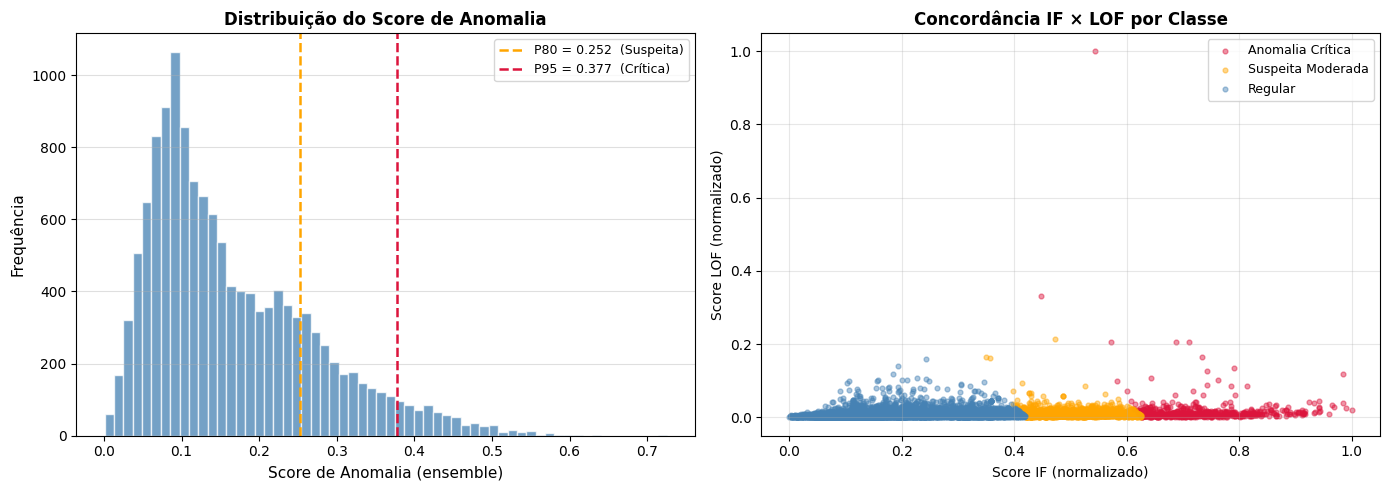

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(score_ensemble, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
ax1.axvline(P80, color='orange', linestyle='--', lw=1.8,
            label=f'P80 = {P80:.3f}  (Suspeita)')
ax1.axvline(P95, color='crimson', linestyle='--', lw=1.8,
            label=f'P95 = {P95:.3f}  (Crítica)')
ax1.set_xlabel('Score de Anomalia (ensemble)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.set_title('Distribuição do Score de Anomalia', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.4)

ax2 = axes[1]
cores = {'Anomalia Crítica': 'crimson', 'Suspeita Moderada': 'orange', 'Regular': 'steelblue'}
for cls, cor in cores.items():
    mask_c = clean_df['classificacao'] == cls
    ax2.scatter(if_norm[mask_c], lof_norm[mask_c],
                c=cor, alpha=0.45, s=12, label=cls, rasterized=True)
ax2.set_xlabel('Score IF (normalizado)')
ax2.set_ylabel('Score LOF (normalizado)')
ax2.set_title('Concordância IF × LOF por Classe', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_01_score_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()


### 11.2 — Importância das Features (Permutation Feature Importance)

Permutamos os valores de uma feature de cada vez e medimos a variação no score
médio do Isolation Forest. Variação grande → feature crítica para o modelo.


Calculando importância das features...


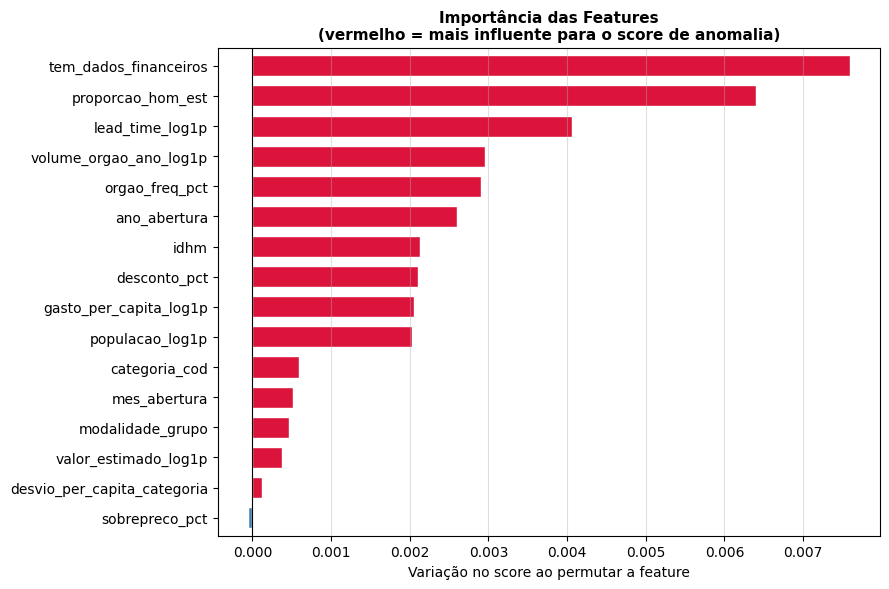

Feature mais importante: tem_dados_financeiros


In [34]:
def calcular_permutation_importance(model, X, feature_names, n_repeats=15, seed=42):
    rng      = np.random.RandomState(seed)
    baseline = -model.score_samples(X).mean()
    imps     = []
    for j in range(X.shape[1]):
        deltas = []
        for _ in range(n_repeats):
            X_p = X.copy()
            rng.shuffle(X_p[:, j])
            deltas.append(-model.score_samples(X_p).mean() - baseline)
        imps.append(np.mean(deltas))
    return pd.Series(imps, index=feature_names).sort_values(ascending=True)


print('Calculando importância das features...')
feat_imp = calcular_permutation_importance(iso_forest, X, NOMES_FEATURES, n_repeats=15)

fig, ax = plt.subplots(figsize=(9, 6))
colors  = ['crimson' if v > 0 else 'steelblue' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white', width=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Variação no score ao permutar a feature', fontsize=10)
ax.set_title('Importância das Features\n'
             '(vermelho = mais influente para o score de anomalia)',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Feature mais importante: {feat_imp.idxmax()}')


### 11.3 — Driver Principal de cada Anomalia

Para cada registro anômalo, calculamos o z-score robusto de cada feature
em relação aos registros Regulares. A feature com maior desvio absoluto é
o **driver** — a principal razão pela qual o modelo marcou o registro como anômalo.


In [35]:
mask_regular   = clean_df['classificacao'] == 'Regular'
feat_regular   = feat[mask_regular]
med_ref        = feat_regular.median()
iqr_ref        = (feat_regular.quantile(0.75) - feat_regular.quantile(0.25)).replace(0, 1)

anomalias_df   = clean_df[clean_df['flag_anomalia']].copy()
feat_anomalias = feat.loc[anomalias_df.index]
z_scores       = (feat_anomalias - med_ref) / iqr_ref

anomalias_df['driver_principal'] = z_scores.abs().idxmax(axis=1)
anomalias_df['z_score_driver']   = z_scores.abs().max(axis=1).round(2)

LABELS_DRIVER = {
    'sobrepreco_pct':              'Sobrepreço',
    'proporcao_hom_est':           'Relação Valor Anômala',
    'valor_estimado_log1p':        'Valor Estimado Atípico',
    'lead_time_log1p':             'Prazo Processual Atípico',
    'desconto_pct':                'Desconto Atípico',
    'modalidade_grupo':            'Modalidade Incomum',
    'orgao_freq_pct':              'Órgão com Padrão Atípico',
    'volume_orgao_ano_log1p':      'Volume Anual Atípico',
    'mes_abertura':                'Sazonalidade Atípica',
    'ano_abertura':                'Padrão Temporal',
    'tem_dados_financeiros':       'Ausência de Dados Financeiros',
    'categoria_cod':               'Categoria Incomum',
    'populacao_log1p':             'Porte Populacional Atípico',
    'idhm':                        'IDHM Atípico',
    'gasto_per_capita_log1p':      'Gasto per Capita Atípico',
    'desvio_per_capita_categoria': 'Desvio per Capita na Categoria',
}
anomalias_df['tipo_anomalia'] = (
    anomalias_df['driver_principal'].map(LABELS_DRIVER).fillna('Outro')
)

print('Drivers principais das anomalias:')
print(anomalias_df['tipo_anomalia'].value_counts().to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(13, max(4, len(anomalias_df) * 0.18)))
sns.heatmap(
    z_scores.clip(-5, 5),
    cmap='RdBu_r', center=0, vmin=-5, vmax=5, ax=ax,
    cbar_kws={'label': 'Z-score robusto vs. grupo Regular'},
    yticklabels=False, linewidths=0.04
)
ax.set_title('Desvio das Anomalias por Feature\n'
             '(vermelho = acima do padrão; azul = abaixo)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_03_heatmap_zscores.png', dpi=150, bbox_inches='tight')
plt.show()


Drivers principais das anomalias:
tipo_anomalia
Porte Populacional Atípico    1805
Valor Estimado Atípico         321
Modalidade Incomum             275
Categoria Incomum              136
Desconto Atípico                91
Sobrepreço                      57
Volume Anual Atípico            16
Gasto per Capita Atípico         4
Prazo Processual Atípico         2
Padrão Temporal                  1


### 11.4 — Anomalias por Categoria de Objeto e Porte de Município

Visualiza a concentração de anomalias por tipo de licitação e faixa de população,
mostrando quais combinações concentram os maiores desvios.


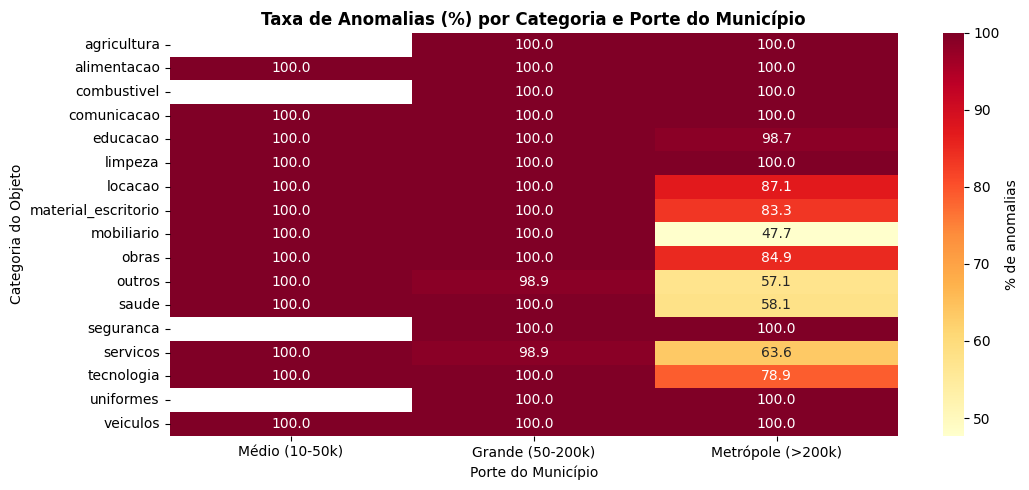

Gasto per capita médio por categoria (R$/habitante):


,Mediana,Média,Máximo,N
categoria_objeto,,,,
obras,137.60,"3,001.34","343,095.45",249
alimentacao,76.33,324.33,"5,998.68",39
agricultura,74.40,927.22,"8,831.23",15
veiculos,70.84,"1,408.09","48,038.21",96
combustivel,66.21,726.76,"9,421.04",16
limpeza,60.90,234.70,"2,713.07",39
locacao,54.78,145.11,"1,190.99",38
uniformes,52.33,169.94,"1,002.68",18
servicos,37.61,"3,991.15","395,291.28",258


In [36]:
clean_df['porte_municipio'] = pd.cut(
    clean_df['populacao'].fillna(0),
    bins=[0, 10_000, 50_000, 200_000, np.inf],
    labels=['Pequeno (<10k)', 'Médio (10-50k)', 'Grande (50-200k)', 'Metrópole (>200k)'],
    right=True
)

pivot = (
    clean_df
    .groupby(['categoria_objeto', 'porte_municipio'], observed=True)['flag_anomalia']
    .mean()
    .unstack('porte_municipio') * 100
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot.round(1), cmap='YlOrRd', annot=True, fmt='.1f', ax=ax,
    cbar_kws={'label': '% de anomalias'}
)
ax.set_title('Taxa de Anomalias (%) por Categoria e Porte do Município',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Categoria do Objeto')
ax.set_xlabel('Porte do Município')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_04_anomalia_categoria_porte.png', dpi=150, bbox_inches='tight')
plt.show()

# Gasto per capita médio por categoria
com_pop = clean_df[clean_df['populacao'].notna() & (clean_df['populacao'] > 0)].copy()
com_pop['gasto_per_capita'] = com_pop['valor_estimado'].fillna(0) / com_pop['populacao']

if len(com_pop) > 0:
    print('Gasto per capita médio por categoria (R$/habitante):')
    resumo_pc = com_pop.groupby('categoria_objeto')['gasto_per_capita'].agg(
        ['median', 'mean', 'max', 'count']
    ).sort_values('median', ascending=False).round(2)
    resumo_pc.columns = ['Mediana', 'Média', 'Máximo', 'N']
    display(resumo_pc)


### 11.5 — Top Anomalias Críticas

In [37]:
cols = [
    'numprocesso', 'ano_abertura', 'modalidade', 'orgao',
    'municipio_extraido', 'populacao', 'idhm', 'categoria_objeto',
    'valor_estimado', 'valor_ou_desconto_homologado',
    'lead_time_dias', 'classificacao', 'score_anomalia', 'tipo_anomalia'
]
cols = [c for c in cols if c in anomalias_df.columns]

print('TOP 20 ANOMALIAS CRÍTICAS (ordenadas por score)')
display(
    anomalias_df[anomalias_df['classificacao'] == 'Anomalia Crítica']
    .sort_values('score_anomalia', ascending=False)
    .head(20)[cols]
)

print('\nTOP 10 SUSPEITAS MODERADAS')
display(
    anomalias_df[anomalias_df['classificacao'] == 'Suspeita Moderada']
    .sort_values('score_anomalia', ascending=False)
    .head(10)[cols]
)


TOP 20 ANOMALIAS CRÍTICAS (ordenadas por score)


,numprocesso,ano_abertura,modalidade,orgao,municipio_extraido,populacao,idhm,categoria_objeto,valor_estimado,valor_ou_desconto_homologado,lead_time_dias,classificacao,score_anomalia,tipo_anomalia
8871,1588,2099,Pregão Eletrônico,UEM-Universidade Estadual de Maringá,Maringá,"429,660.00",0.68,saude,"13,985,901.00",NaN,NaN,Anomalia Crítica,0.73,Padrão Temporal
4687,2,2023,Licitação Presencial - Estatal,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,"150,104.00",0.75,obras,"914,942,160.00","3,515,226,100.00",61.00,Anomalia Crítica,0.64,Sobrepreço
1985,248,2025,Concorrência Eletrônica (Lei Federal 14.133/2021),UEPG-Universidade Estadual de Ponta Grossa,Ponta Grossa,"375,632.00",0.70,obras,"1,217,184,952.00","1,758.00",63.00,Anomalia Crítica,0.61,Porte Populacional Atípico
1885,139,2025,Concorrência Eletrônica (Lei Federal 14.133/2021),UEPG-Universidade Estadual de Ponta Grossa,Ponta Grossa,"375,632.00",0.70,obras,"10,707,328,790.00","10,706,000,000.00",47.00,Anomalia Crítica,0.61,Porte Populacional Atípico
4683,17,2024,Licitação Eletrônica - Estatal,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,"150,104.00",0.75,servicos,"28,516,784,193.00",1.00,40.00,Anomalia Crítica,0.60,Gasto per Capita Atípico
9942,134,2021,Concorrência Pública,UNIOESTE FBELT-Universidade Estadual do Oeste do Paraná - Campus Francisco Beltrão,Francisco Beltrão,"102,312.00",0.75,educacao,"71,517,800.00",NaN,NaN,Anomalia Crítica,0.59,Porte Populacional Atípico
7367,6,2022,Licitação Presencial - Estatal,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,"150,104.00",0.75,servicos,"59,334,801,967.00",10.00,76.00,Anomalia Crítica,0.59,Gasto per Capita Atípico
116,72,2025,Concorrência Eletrônica (Lei Federal 14.133/2021),UEL-Universidade Estadual de Londrina,Londrina,"581,382.00",0.72,veiculos,"3,224,425,182.00",NaN,NaN,Anomalia Crítica,0.58,Porte Populacional Atípico
7357,6,2022,Licitação Eletrônica - Estatal,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,"150,104.00",0.75,obras,"2,275,462,161.00","1,501.00",125.00,Anomalia Crítica,0.58,Porte Populacional Atípico
4656,25,2023,Credenciamento,FA-Fundação Araucária,Araucária,"162,247.00",0.70,alimentacao,"156,600,000.00","156,600,000.00",11.00,Anomalia Crítica,0.58,Porte Populacional Atípico



TOP 10 SUSPEITAS MODERADAS


,numprocesso,ano_abertura,modalidade,orgao,municipio_extraido,populacao,idhm,categoria_objeto,valor_estimado,valor_ou_desconto_homologado,lead_time_dias,classificacao,score_anomalia,tipo_anomalia
5227,570,2023,Pregão Eletrônico,UEPG-Universidade Estadual de Ponta Grossa,Ponta Grossa,"375,632.00",0.70,agricultura,"44,925,000.00","31,497,850.00",38.00,Suspeita Moderada,0.38,Porte Populacional Atípico
4651,16,2023,Credenciamento,LOTTOPAR-Loteria do Estado do Paraná,None,NaN,NaN,saude,0.00,NaN,NaN,Suspeita Moderada,0.38,Valor Estimado Atípico
2225,101,2024,Pregão Eletrônico,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,"150,104.00",0.75,servicos,"138,955,744.00","99,776,000.00",26.00,Suspeita Moderada,0.38,Porte Populacional Atípico
1105,856,2025,Pregão Eletrônico (Lei Federal 14.133/2021),UEPG-Universidade Estadual de Ponta Grossa,Ponta Grossa,"375,632.00",0.70,combustivel,"19,168,000.00","18,496,000.00",7.00,Suspeita Moderada,0.38,Porte Populacional Atípico
3660,1503,2024,Pregão Eletrônico (Lei Federal 14.133/2021),UEM-Universidade Estadual de Maringá,Maringá,"429,660.00",0.68,saude,"260,115,926.00",NaN,0.00,Suspeita Moderada,0.38,Porte Populacional Atípico
7111,2,2022,Chamamento Público,SEAP-Secretaria de Estado da Administração e da Previdência,None,NaN,NaN,tecnologia,0.00,NaN,NaN,Suspeita Moderada,0.38,Valor Estimado Atípico
3205,1011,2024,Pregão Eletrônico (Lei Federal 14.133/2021),UNIOESTE FOZ-Universidade Estadual do Oeste do Paraná - Campus Foz do Iguaçu,Foz do Iguaçu,"297,352.00",0.73,combustivel,"15,987,000.00",NaN,13.00,Suspeita Moderada,0.38,Porte Populacional Atípico
11226,1320,2021,Pregão Eletrônico,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,"150,104.00",0.75,outros,"58,569,700.00","32,164,550.00",83.00,Suspeita Moderada,0.38,Porte Populacional Atípico
13477,1628,2020,Pregão Eletrônico,UEPG-Universidade Estadual de Ponta Grossa,Ponta Grossa,"375,632.00",0.70,servicos,"12,144,000.00","11,800,020.00",24.00,Suspeita Moderada,0.38,Porte Populacional Atípico
7105,4,2022,Audiência Pública,CASA MILITAR-Casa Militar do Estado do Paraná,None,NaN,NaN,servicos,0.00,NaN,NaN,Suspeita Moderada,0.38,Valor Estimado Atípico


### 11.6 — SHAP (Interpretabilidade por Instância)

Calculando SHAP values...


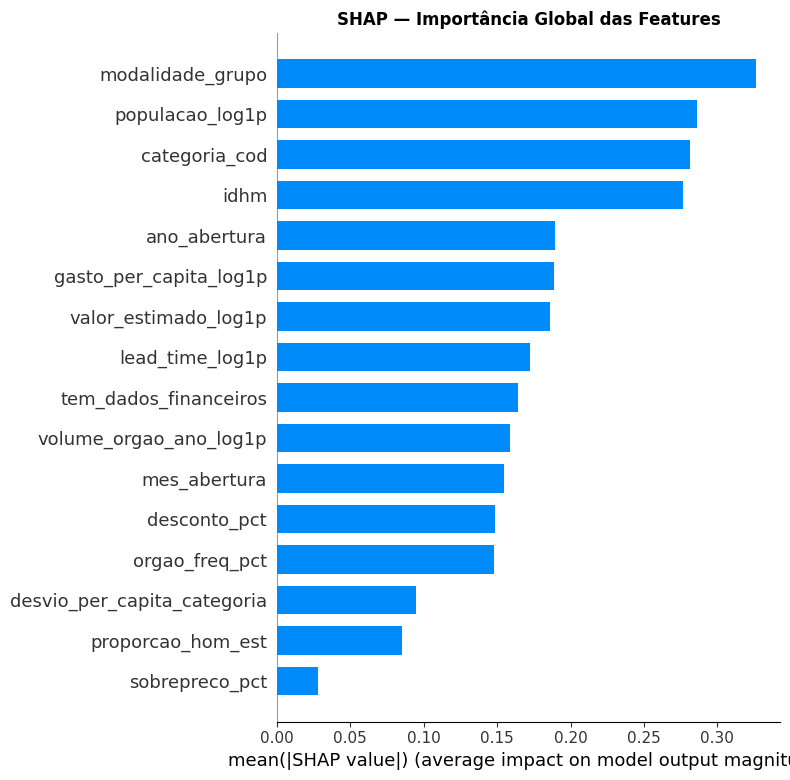

In [38]:
if SHAP_DISPONIVEL:
    print('Calculando SHAP values...')
    explainer   = shap.TreeExplainer(iso_forest)
    shap_values = explainer.shap_values(X)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X, feature_names=NOMES_FEATURES,
                      show=False, plot_type='bar')
    plt.title('SHAP — Importância Global das Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(EXPORTS_DIR / 'fig_05_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('SHAP não instalado. Para ativar: pip install shap  e reiniciar o kernel.')


---
## 12 — Exportação dos Resultados

In [ ]:
export_df = clean_df.sort_values('score_anomalia', ascending=False).copy()
export_df = export_df.merge(
    anomalias_df[['driver_principal', 'tipo_anomalia', 'z_score_driver']],
    left_index=True, right_index=True, how='left'
)

path_completo  = EXPORTS_DIR / 'licitacoes_com_score_ml.csv'
path_anomalias = EXPORTS_DIR / 'licitacoes_anomalias_ml.csv'

export_df.to_csv(path_completo, sep=';', index=False)
anomalias_df.sort_values('score_anomalia', ascending=False).to_csv(
    path_anomalias, sep=';', index=False
)

print('Arquivos exportados:')
print(f'  {path_completo.name}:  {len(export_df):,} registros')
print(f'  {path_anomalias.name}: {len(anomalias_df):,} registros')


Arquivos exportados:
  5_licitacoes_com_score_ml.csv:  13,536 registros
  6_licitacoes_anomalias_ml.csv: 2,708 registros


---
## 13 — Sumário Final e Limitações

In [40]:
n_criticas  = (clean_df['classificacao'] == 'Anomalia Crítica').sum()
n_suspeitas = (clean_df['classificacao'] == 'Suspeita Moderada').sum()
n_regular   = (clean_df['classificacao'] == 'Regular').sum()
n_total     = len(clean_df)
ano_min     = clean_df['ano_abertura'][clean_df['ano_abertura'] > 0].min()
ano_max     = clean_df['ano_abertura'].max()

print('=' * 72)
print('  SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES PÚBLICAS DO PARANÁ')
print('=' * 72)
print(f'  Período analisado              : {ano_min} – {ano_max}')
print(f'  Total de registros             : {n_total:,}')
print(f'  Municípios identificados       : {clean_df["municipio_extraido"].notna().sum():,}')
print(f'  Com dados IDHM/pop             : {clean_df["populacao"].notna().sum():,}')
print()
print(f'  Anomalias Críticas   (≥ P95)   : {n_criticas:,}  ({n_criticas/n_total*100:.1f}%)')
print(f'  Suspeitas Moderadas  (≥ P80)   : {n_suspeitas:,}  ({n_suspeitas/n_total*100:.1f}%)')
print(f'  Regulares            (< P80)   : {n_regular:,}  ({n_regular/n_total*100:.1f}%)')
print()
print('  METODOLOGIA')
print(f'    Algoritmos   : Isolation Forest + LOF (ensemble {PESO_IF:.0%}/{PESO_LOF:.0%})')
print(f'    Features     : {len(NOMES_FEATURES)} variáveis (financeiras, temporais, IDHM)')
print(f'    Threshold    : P95 = {P95:.4f} (Crítica)  |  P80 = {P80:.4f} (Suspeita)')
print()
print('  LIMITAÇÕES')
print('  1. SEM RÓTULOS: resultados indicam desvio estatístico, não fraude confirmada.')
print('     Registros anômalos requerem revisão manual.')
print('  2. IDHM 2010: último censo disponível. Mudanças desde 2010 não estão refletidas.')
print('  3. MUNICÍPIO: órgãos estaduais (sem município no nome) não têm per capita.')
print('     Contribuem apenas com features não-contextuais (valor, lead time, etc.).')
print('=' * 72)


  SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES PÚBLICAS DO PARANÁ
  Período analisado              : 2018 – 2099
  Total de registros             : 13,536
  Municípios identificados       : 2,457
  Com dados IDHM/pop             : 2,457

  Anomalias Críticas   (≥ P95)   : 677  (5.0%)
  Suspeitas Moderadas  (≥ P80)   : 2,031  (15.0%)
  Regulares            (< P80)   : 10,828  (80.0%)

  METODOLOGIA
    Algoritmos   : Isolation Forest + LOF (ensemble 60%/40%)
    Features     : 16 variáveis (financeiras, temporais, IDHM)
    Threshold    : P95 = 0.3771 (Crítica)  |  P80 = 0.2522 (Suspeita)

  LIMITAÇÕES
  1. SEM RÓTULOS: resultados indicam desvio estatístico, não fraude confirmada.
     Registros anômalos requerem revisão manual.
  2. IDHM 2010: último censo disponível. Mudanças desde 2010 não estão refletidas.
  3. MUNICÍPIO: órgãos estaduais (sem município no nome) não têm per capita.
     Contribuem apenas com features não-contextuais (valor, lead time, etc.).
